# Canadian Global Deterministic Prediction System (GDPS)

In this example, we will complete the following:

1) Download the first 24 hours of GDPS Data for Geopotential Height, Relative Vorticity, U-Wind and V-Wind at 500mb
2) We will create a set of graphics of 500mb Geopotential Height, Relative Vorticity and Wind for the next 24 hours.

[***WxData GDPS Client Documentation***](https://edrewitz.github.io/WxData/gdps)

## Imports

In [1]:
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import cartopy.feature as cfeature
import numpy as np
import metpy.plots as mpplots
import pandas as pd

from wxdata import gdps
from matplotlib.colors import LinearSegmentedColormap
from matplotlib.patheffects import withStroke 
from datetime import timedelta

# IPython magic command used in Jupyter Notebooks to display plots directly below the code cell that generates them
%matplotlib inline

### WxData GDPS Client

```python
def gdps(final_forecast_hour=240, 
             western_bound=-180, 
             eastern_bound=180, 
             northern_bound=90, 
             southern_bound=-90, 
             step=1,
             path=f"GDPS",
             proxies=None, 
             clear_recycle_bin=False,
             process_data=True,
             convert_temperature=True,
             convert_to='celsius',
             chunk_size=8192,
             notifications='off',
             level_type='pressure',
             clear_data=False,
            variable='geopotential height',
            level=500,
            layer=[1000, 500]):
```

In this example, we will not need to change level as 500mb is our default, we do not need to touch layer as that is for a `level_type` of `'pressure layer` or `'depth below surface'` and we do not need to change our `level_type` as pressure is our default.

We will need to change `variable` for each data array. 

We will also change our `final_forecast_hour=24` from the default `final_forecast_hour=240` as we only want to download the first 24 hours worth of data.

In [2]:
height = gdps(final_forecast_hour=24,
              western_bound=-130,
              eastern_bound=-65,
              northern_bound=60,
              southern_bound=20)

Scanning https://dd.weather.gc.ca/ GDPS GEOPOTENTIAL HEIGHT 500mb
Please Wait...
Server Scan Complete!


20260820T12Z_MSC_GDPS_GeopotentialHeight_IsbL-0500_LatLon0.15_PT000H.grib2:   0%|          | 0.00/634k [00:00<…

20260820T12Z_MSC_GDPS_GeopotentialHeight_IsbL-0500_LatLon0.15_PT003H.grib2:   0%|          | 0.00/611k [00:00<…

20260820T12Z_MSC_GDPS_GeopotentialHeight_IsbL-0500_LatLon0.15_PT006H.grib2:   0%|          | 0.00/612k [00:00<…

20260820T12Z_MSC_GDPS_GeopotentialHeight_IsbL-0500_LatLon0.15_PT009H.grib2:   0%|          | 0.00/617k [00:00<…

...

20260820T12Z_MSC_GDPS_GeopotentialHeight_IsbL-0500_LatLon0.15_PT015H.grib2:   0%|          | 0.00/613k [00:00<…

20260820T12Z_MSC_GDPS_GeopotentialHeight_IsbL-0500_LatLon0.15_PT018H.grib2:   0%|          | 0.00/614k [00:00<…

20260820T12Z_MSC_GDPS_GeopotentialHeight_IsbL-0500_LatLon0.15_PT021H.grib2:   0%|          | 0.00/614k [00:00<…

20260820T12Z_MSC_GDPS_GeopotentialHeight_IsbL-0500_LatLon0.15_PT024H.grib2:   0%|          | 0.00/611k [00:00<…

GDPS GEOPOTENTIAL HEIGHT 500mb Download Complete!

Data Processing...
GDPS Data Processing Complete: GEOPOTENTIAL HEIGHT - 500mb


In [3]:
vorticity = gdps(final_forecast_hour=24,
              western_bound=-130,
              eastern_bound=-65,
              northern_bound=60,
              southern_bound=20,
              variable='relative vorticity')

Scanning https://dd.weather.gc.ca/ GDPS RELATIVE VORTICITY 500mb
Please Wait...
Server Scan Complete!


20260820T12Z_MSC_GDPS_RelativeVorticity_IsbL-0500_LatLon0.15_PT000H.grib2:   0%|          | 0.00/1.51M [00:00<…

20260820T12Z_MSC_GDPS_RelativeVorticity_IsbL-0500_LatLon0.15_PT003H.grib2:   0%|          | 0.00/1.24M [00:00<…

20260820T12Z_MSC_GDPS_RelativeVorticity_IsbL-0500_LatLon0.15_PT006H.grib2:   0%|          | 0.00/1.52M [00:00<…

20260820T12Z_MSC_GDPS_RelativeVorticity_IsbL-0500_LatLon0.15_PT009H.grib2:   0%|          | 0.00/1.51M [00:00<…

...

20260820T12Z_MSC_GDPS_RelativeVorticity_IsbL-0500_LatLon0.15_PT015H.grib2:   0%|          | 0.00/1.51M [00:00<…

20260820T12Z_MSC_GDPS_RelativeVorticity_IsbL-0500_LatLon0.15_PT018H.grib2:   0%|          | 0.00/1.50M [00:00<…

20260820T12Z_MSC_GDPS_RelativeVorticity_IsbL-0500_LatLon0.15_PT021H.grib2:   0%|          | 0.00/1.23M [00:00<…

20260820T12Z_MSC_GDPS_RelativeVorticity_IsbL-0500_LatLon0.15_PT024H.grib2:   0%|          | 0.00/1.55M [00:00<…

GDPS RELATIVE VORTICITY 500mb Download Complete!

Data Processing...
GDPS Data Processing Complete: RELATIVE VORTICITY - 500mb


In [4]:
u_wind = gdps(final_forecast_hour=24,
              western_bound=-130,
              eastern_bound=-65,
              northern_bound=60,
              southern_bound=20,
              variable='u-component of wind')

Scanning https://dd.weather.gc.ca/ GDPS U-COMPONENT OF WIND 500mb
Please Wait...
Server Scan Complete!


20260820T12Z_MSC_GDPS_WindU_IsbL-0500_LatLon0.15_PT000H.grib2:   0%|          | 0.00/1.17M [00:00<?, ?B/s]

20260820T12Z_MSC_GDPS_WindU_IsbL-0500_LatLon0.15_PT003H.grib2:   0%|          | 0.00/1.16M [00:00<?, ?B/s]

20260820T12Z_MSC_GDPS_WindU_IsbL-0500_LatLon0.15_PT006H.grib2:   0%|          | 0.00/1.17M [00:00<?, ?B/s]

20260820T12Z_MSC_GDPS_WindU_IsbL-0500_LatLon0.15_PT009H.grib2:   0%|          | 0.00/1.17M [00:00<?, ?B/s]

...

20260820T12Z_MSC_GDPS_WindU_IsbL-0500_LatLon0.15_PT015H.grib2:   0%|          | 0.00/1.16M [00:00<?, ?B/s]

20260820T12Z_MSC_GDPS_WindU_IsbL-0500_LatLon0.15_PT018H.grib2:   0%|          | 0.00/1.16M [00:00<?, ?B/s]

20260820T12Z_MSC_GDPS_WindU_IsbL-0500_LatLon0.15_PT021H.grib2:   0%|          | 0.00/1.16M [00:00<?, ?B/s]

20260820T12Z_MSC_GDPS_WindU_IsbL-0500_LatLon0.15_PT024H.grib2:   0%|          | 0.00/1.16M [00:00<?, ?B/s]

GDPS U-COMPONENT OF WIND 500mb Download Complete!

Data Processing...
GDPS Data Processing Complete: U-COMPONENT OF WIND - 500mb


In [5]:
v_wind = gdps(final_forecast_hour=24,
              western_bound=-130,
              eastern_bound=-65,
              northern_bound=60,
              southern_bound=20,
              variable='v-component of wind')

Scanning https://dd.weather.gc.ca/ GDPS V-COMPONENT OF WIND 500mb
Please Wait...
Server Scan Complete!


20260820T12Z_MSC_GDPS_WindV_IsbL-0500_LatLon0.15_PT000H.grib2:   0%|          | 0.00/1.16M [00:00<?, ?B/s]

20260820T12Z_MSC_GDPS_WindV_IsbL-0500_LatLon0.15_PT003H.grib2:   0%|          | 0.00/1.16M [00:00<?, ?B/s]

20260820T12Z_MSC_GDPS_WindV_IsbL-0500_LatLon0.15_PT006H.grib2:   0%|          | 0.00/1.16M [00:00<?, ?B/s]

20260820T12Z_MSC_GDPS_WindV_IsbL-0500_LatLon0.15_PT009H.grib2:   0%|          | 0.00/1.16M [00:00<?, ?B/s]

...

20260820T12Z_MSC_GDPS_WindV_IsbL-0500_LatLon0.15_PT015H.grib2:   0%|          | 0.00/1.15M [00:00<?, ?B/s]

20260820T12Z_MSC_GDPS_WindV_IsbL-0500_LatLon0.15_PT018H.grib2:   0%|          | 0.00/1.15M [00:00<?, ?B/s]

20260820T12Z_MSC_GDPS_WindV_IsbL-0500_LatLon0.15_PT021H.grib2:   0%|          | 0.00/900k [00:00<?, ?B/s]

20260820T12Z_MSC_GDPS_WindV_IsbL-0500_LatLon0.15_PT024H.grib2:   0%|          | 0.00/902k [00:00<?, ?B/s]

GDPS V-COMPONENT OF WIND 500mb Download Complete!

Data Processing...
GDPS Data Processing Complete: V-COMPONENT OF WIND - 500mb


## Inspecting Our Data

In [6]:
height

<xarray.Dataset> Size: 4MB
Dimensions:              (step: 9, latitude: 266, longitude: 433)
Coordinates:
  * step                 (step) float64 72B 0.0 3.0 6.0 9.0 ... 18.0 21.0 24.0
  * latitude             (latitude) float64 2kB 20.1 20.25 20.4 ... 59.7 59.85
  * longitude            (longitude) float64 3kB -129.9 -129.7 ... -65.25 -65.1
    time                 datetime64[ns] 8B ...
    isobaricInhPa        float64 8B ...
    valid_time           datetime64[ns] 8B ...
Data variables:
    geopotential_height  (step, latitude, longitude) float32 4MB dask.array<chunksize=(1, 266, 433), meta=np.ndarray>
Attributes:
    GRIB_edition:            2
    GRIB_centre:             cwao
    GRIB_centreDescription:  Canadian Meteorological Service - Montreal
    GRIB_subCentre:          0
    Conventions:             CF-1.7
    institution:             Canadian Meteorological Service - Montreal
    history:                 2026-08-20T16:47 GRIB to CDM+CF via cfgrib-0.9.1...

In [7]:
vorticity

<xarray.Dataset> Size: 4MB
Dimensions:             (step: 9, latitude: 266, longitude: 433)
Coordinates:
  * step                (step) float64 72B 0.0 3.0 6.0 9.0 ... 18.0 21.0 24.0
  * latitude            (latitude) float64 2kB 20.1 20.25 20.4 ... 59.7 59.85
  * longitude           (longitude) float64 3kB -129.9 -129.7 ... -65.25 -65.1
    time                datetime64[ns] 8B ...
    isobaricInhPa       float64 8B ...
    valid_time          datetime64[ns] 8B ...
Data variables:
    relative_vorticity  (step, latitude, longitude) float32 4MB dask.array<chunksize=(1, 266, 433), meta=np.ndarray>
Attributes:
    GRIB_edition:            2
    GRIB_centre:             cwao
    GRIB_centreDescription:  Canadian Meteorological Service - Montreal
    GRIB_subCentre:          0
    Conventions:             CF-1.7
    institution:             Canadian Meteorological Service - Montreal
    history:                 2026-08-20T16:47 GRIB to CDM+CF via cfgrib-0.9.1...

In [8]:
u_wind

<xarray.Dataset> Size: 4MB
Dimensions:              (step: 9, latitude: 266, longitude: 433)
Coordinates:
  * step                 (step) float64 72B 0.0 3.0 6.0 9.0 ... 18.0 21.0 24.0
  * latitude             (latitude) float64 2kB 20.1 20.25 20.4 ... 59.7 59.85
  * longitude            (longitude) float64 3kB -129.9 -129.7 ... -65.25 -65.1
    time                 datetime64[ns] 8B ...
    isobaricInhPa        float64 8B ...
    valid_time           datetime64[ns] 8B ...
Data variables:
    u-component_of_wind  (step, latitude, longitude) float32 4MB dask.array<chunksize=(1, 266, 433), meta=np.ndarray>
Attributes:
    GRIB_edition:            2
    GRIB_centre:             cwao
    GRIB_centreDescription:  Canadian Meteorological Service - Montreal
    GRIB_subCentre:          0
    Conventions:             CF-1.7
    institution:             Canadian Meteorological Service - Montreal
    history:                 2026-08-20T16:47 GRIB to CDM+CF via cfgrib-0.9.1...

In [9]:
v_wind

<xarray.Dataset> Size: 4MB
Dimensions:              (step: 9, latitude: 266, longitude: 433)
Coordinates:
  * step                 (step) float64 72B 0.0 3.0 6.0 9.0 ... 18.0 21.0 24.0
  * latitude             (latitude) float64 2kB 20.1 20.25 20.4 ... 59.7 59.85
  * longitude            (longitude) float64 3kB -129.9 -129.7 ... -65.25 -65.1
    time                 datetime64[ns] 8B ...
    isobaricInhPa        float64 8B ...
    valid_time           datetime64[ns] 8B ...
Data variables:
    v-component_of_wind  (step, latitude, longitude) float32 4MB dask.array<chunksize=(1, 266, 433), meta=np.ndarray>
Attributes:
    GRIB_edition:            2
    GRIB_centre:             cwao
    GRIB_centreDescription:  Canadian Meteorological Service - Montreal
    GRIB_subCentre:          0
    Conventions:             CF-1.7
    institution:             Canadian Meteorological Service - Montreal
    history:                 2026-08-20T16:48 GRIB to CDM+CF via cfgrib-0.9.1...

## Creating Our Plot

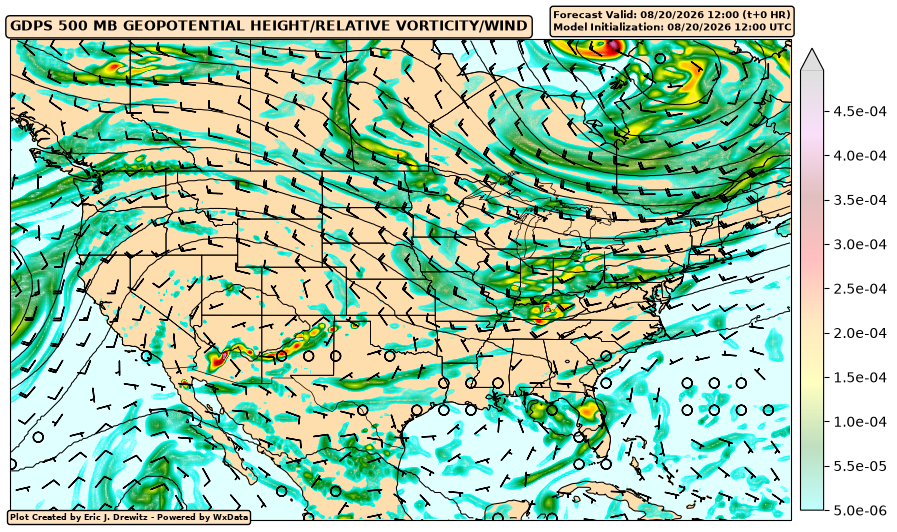

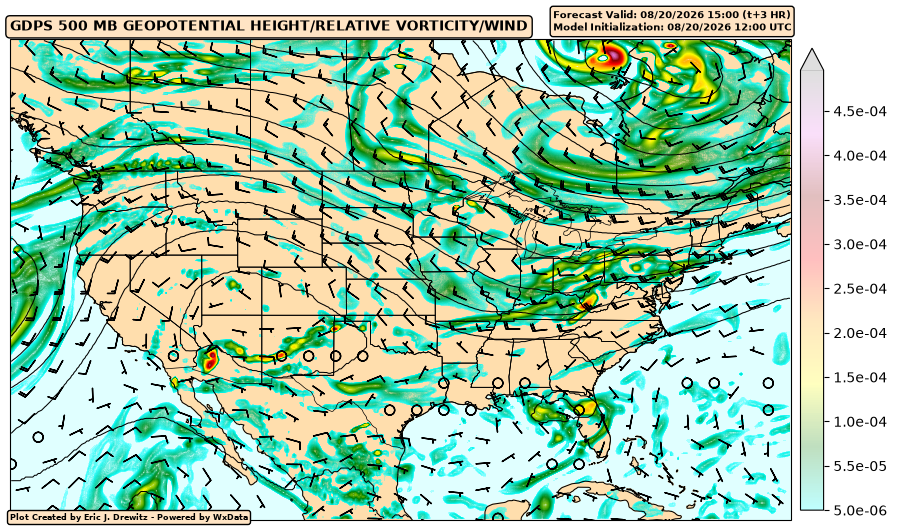

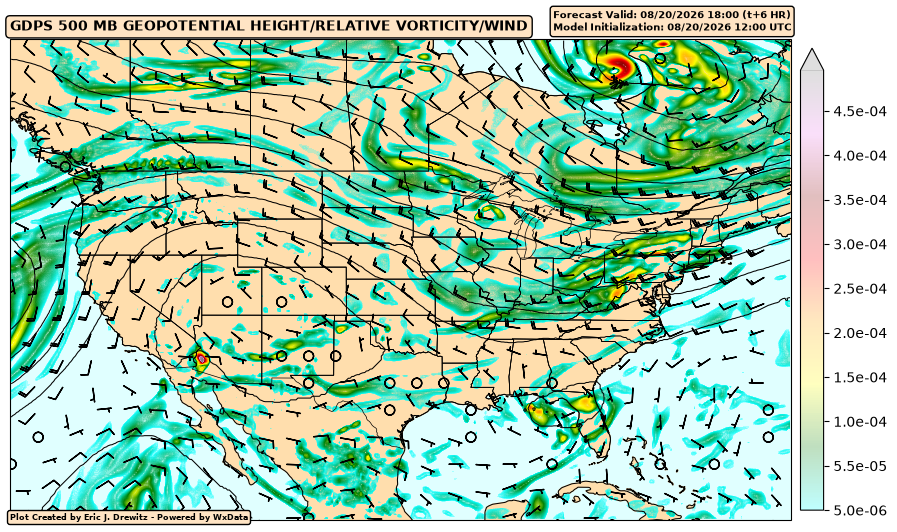

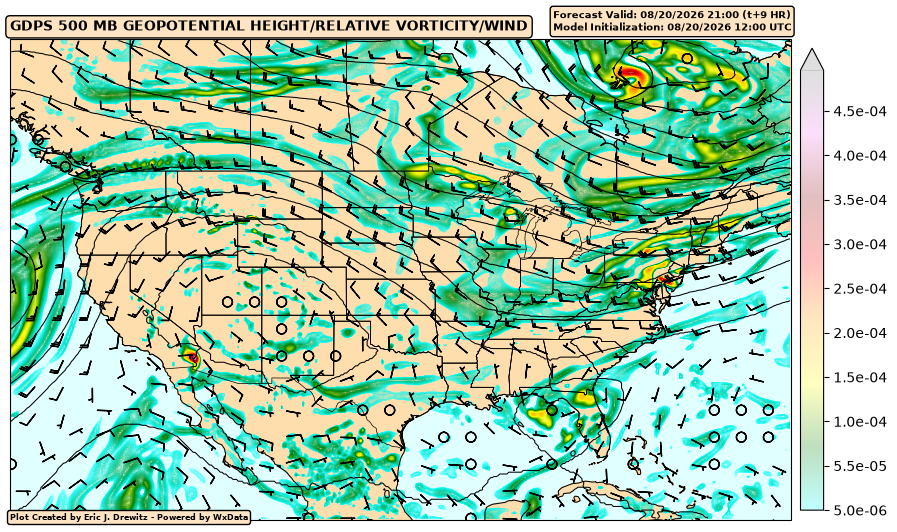

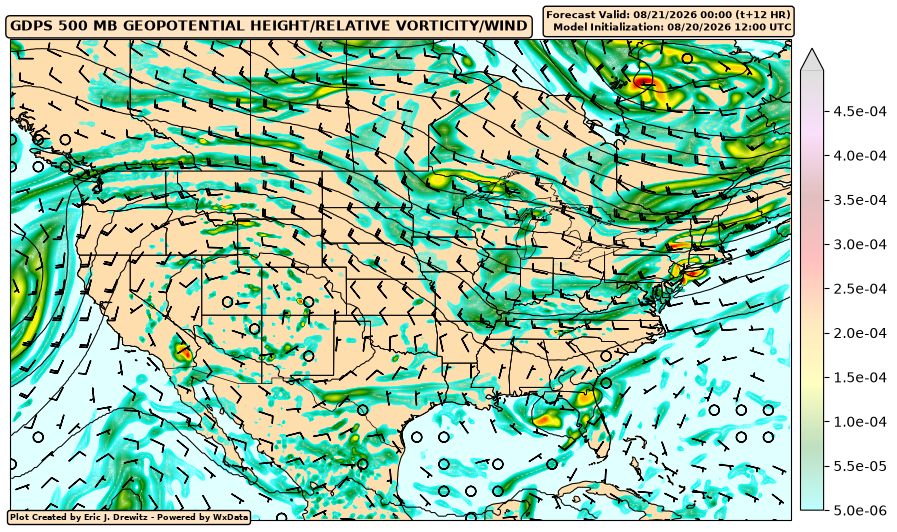

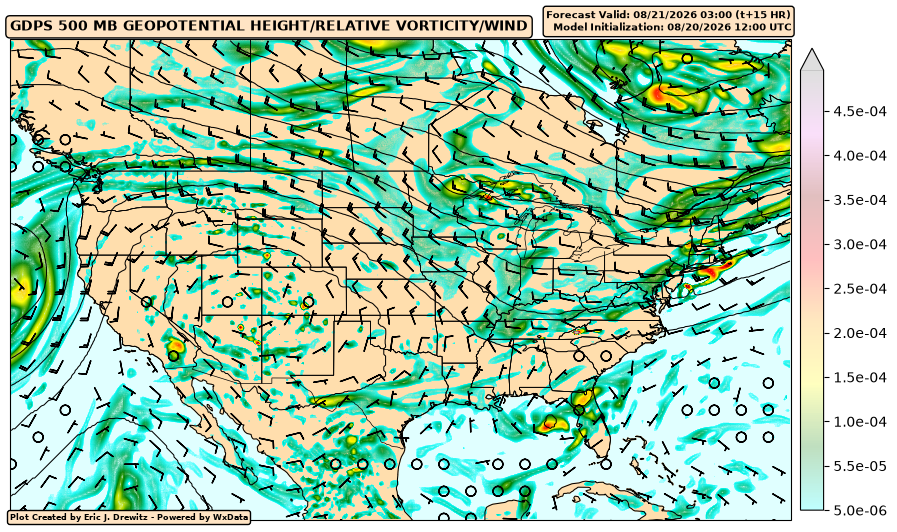

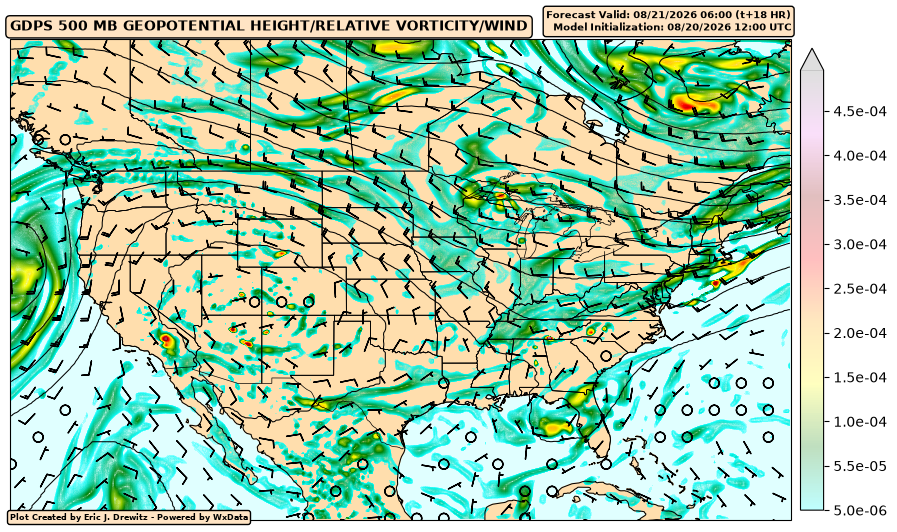

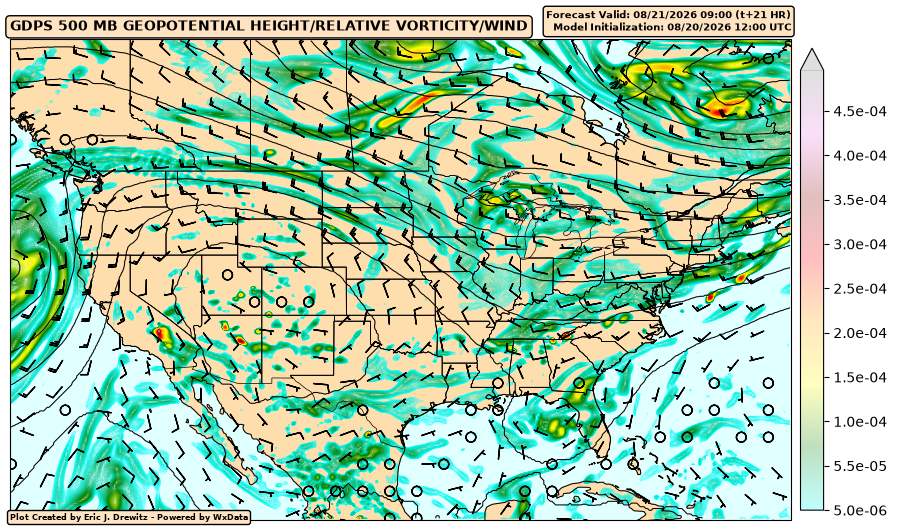

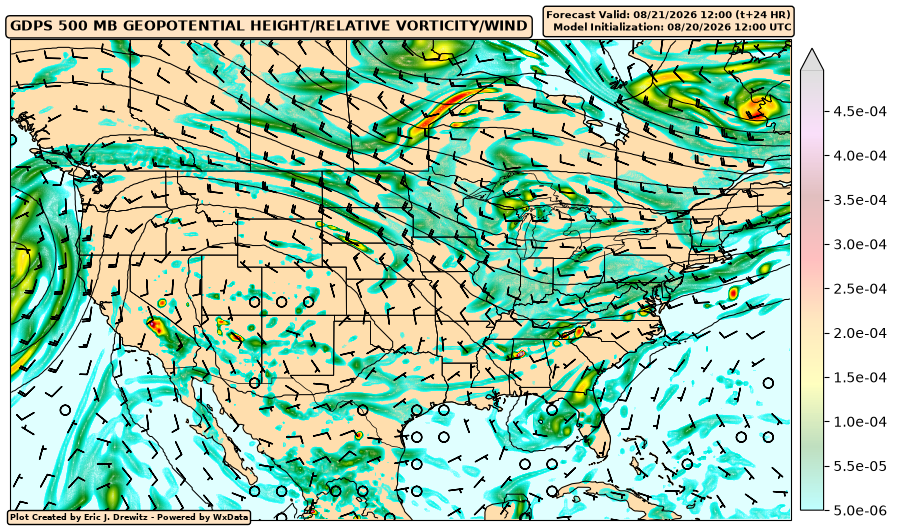

In [10]:
# Create our figure
for i in range(0, len(height['step']), 1):
    fig = plt.figure(figsize=(12,12))
    
    # Create our subplot with a PlateCarree (lat/lon) projection
    ax = fig.add_subplot(1,1,1, projection=ccrs.PlateCarree())
    
    # Set our boundaries in a latlon format of [western_bound, eastern_bound, southern_bound, northern_bound] followed by our PlateCarree projection
    ax.set_extent([-130, -65, 20, 60], ccrs.PlateCarree())
    
    # Add our features to the map 
    # Add our coastlines
    ax.add_feature(cfeature.COASTLINE.with_scale('50m'), linewidth=0.75, zorder=3)
    
    # Add the oceans, land, states, lakes and Canadian provinces and color them light cyan
    ax.add_feature(cfeature.OCEAN, color='lightcyan', zorder=1)
    ax.add_feature(cfeature.LAKES, color='lightcyan', zorder=1)
    ax.add_feature(cfeature.LAND, color='navajowhite', zorder=1)
    ax.add_feature(cfeature.STATES, edgecolor='black', linewidth=0.5, zorder=5)
    province_boundaries = cfeature.NaturalEarthFeature(
        category="cultural",
        name="admin_1_states_provinces_lines",
        scale="50m",
        facecolor="none",
        edgecolor="black",
    )
    ax.add_feature(province_boundaries, linewidth=0.5, zorder=5)
    
    cmap = LinearSegmentedColormap.from_list("relative vorticity", 
                                             ['cyan',
                                             'green',
                                             'yellow',
                                             'orange',
                                             'red',
                                             'darkred',
                                             'violet',
                                             'gray'])
    # Add our geopotential height contours
    c = ax.contour(height['longitude'], 
                   height['latitude'], 
                   (height['geopotential_height'][i, :, :]/ 10), 
                   levels=np.arange(480, 608, 4), 
                   transform=ccrs.PlateCarree(), 
                   colors='black', 
                   linewidths=0.75)
    
    # Add our filled contours for relative vorticity
    cs = ax.contourf(vorticity['longitude'], 
                   vorticity['latitude'], 
                   vorticity['relative_vorticity'][i, :, :], 
                   levels=np.arange(0.000005, (0.0005 + 0.000001), 0.000001), 
                   transform=ccrs.PlateCarree(),
                   alpha=0.25,
                   cmap=cmap,
                   extend='max')
    
    # Create our colorbar for our filled contours
    fig.colorbar(cs, 
                 shrink=0.5, 
                 pad=0.01,
                format='%.1e')
    
    # Get our filtered latitude and longitude values to plot our wind barbs
    plot_lon, plot_lat = np.meshgrid(u_wind['longitude'][::15], 
                                      u_wind['latitude'][::15])
    
    # Create our wind barbs
    barbs = mpplots.StationPlot(ax, plot_lon.flatten(), plot_lat.flatten(),
                                    transform=ccrs.PlateCarree(), 
                                    clip_on=True)
    
    # Filter our u and v wind components to the same decimation as our barbs
    # Gets the value for u and v every 15 data points
    u = u_wind['u-component_of_wind'][i, ::15, ::15].to_numpy().flatten()
    v = v_wind['v-component_of_wind'][i, ::15, ::15].to_numpy().flatten()
    
    # Plot our wind barbs
    barbs.plot_barb(u, 
                  v,
                  color='black',
                  length=4.5)
    
    # Plot title
    plt.title(f"GDPS 500 MB GEOPOTENTIAL HEIGHT/RELATIVE VORTICITY/WIND", 
                   fontsize=10, 
                   fontweight='bold',
                   bbox=dict(boxstyle='round', 
                                facecolor='bisque'),
                   loc='left')
    
    # Extract our valid time as a datetime object
    valid_time = pd.to_datetime(height['valid_time'].values)
    
    # Gets our new forecast hour (eventhough we are plotting the initial frame)
    times = height['step'].values
    forecast_time = valid_time + timedelta(hours=int(times[i]))
    
    # Secondary title for our model runtime
    plt.title(f"Forecast Valid: {forecast_time.strftime('%m/%d/%Y %H:00')} (t+{int(times[i])} HR)\nModel Initialization: {valid_time.strftime('%m/%d/%Y %H:00')} UTC", 
                    fontsize=7, 
                    fontweight='bold',
                    bbox=dict(boxstyle='round', 
                                facecolor='bisque'),
                    loc='right')
    
    # Adding my signature on the plot
    ax.text(0, 
            -0.001, 
            f"Plot Created by Eric J. Drewitz - Powered by WxData", 
            transform=ax.transAxes, 
            fontsize=6, 
            fontweight='bold', 
            bbox=dict(boxstyle='round', 
                    facecolor='bisque'))

    plt.show()